# Advanced Mutual Fund Analytics

This notebook performs comprehensive advanced analyses on mutual fund data including:
- VaR & CVaR calculations
- Rolling Sharpe ratio analysis
- Investor cohort analysis  
- SIP continuity risk assessment
- Fund recommender system
- Sector concentration (HHI) analysis

## Section 1: Import Libraries and Load Data

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Load data
fund_master = pd.read_csv('data/processed/01_fund_master_clean.csv')
nav_history = pd.read_csv('data/processed/02_nav_history_clean.csv')
performance = pd.read_csv('data/processed/07_scheme_performance_clean.csv')
transactions = pd.read_csv('data/processed/08_investor_transactions_clean.csv')
portfolio_holdings = pd.read_csv('data/processed/09_portfolio_holdings.csv')

# Convert dates
nav_history['date'] = pd.to_datetime(nav_history['date'])
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
portfolio_holdings['portfolio_date'] = pd.to_datetime(portfolio_holdings['portfolio_date'])

print("✓ Data loaded successfully")
print(f"Fund Master: {fund_master.shape}")
print(f"NAV History: {nav_history.shape}")
print(f"Performance: {performance.shape}")
print(f"Transactions: {transactions.shape}")
print(f"Portfolio Holdings: {portfolio_holdings.shape}")

✓ Data loaded successfully
Fund Master: (40, 15)
NAV History: (53822, 3)
Performance: (40, 19)
Transactions: (13062, 13)
Portfolio Holdings: (322, 8)


## Section 2: Historical VaR and CVaR Calculation

VaR (Value at Risk) at 95% confidence represents the 5th percentile of daily returns.
CVaR (Conditional VaR) is the mean of returns below the VaR threshold - a more severe risk measure.

In [11]:
# Calculate daily returns from NAV history
nav_pivot = nav_history.pivot_table(
    index='date', 
    columns='amfi_code', 
    values='nav'
).sort_index()

# Calculate daily returns (percentage change)
daily_returns = nav_pivot.pct_change().dropna()

# Calculate VaR (95%) and CVaR for all funds
var_cvar_results = []

for amfi_code in daily_returns.columns:
    returns = daily_returns[amfi_code].dropna()
    
    if len(returns) > 0:
        # VaR at 95% = 5th percentile (worst 5% of losses)
        var_95 = returns.quantile(0.05)
        
        # CVaR = mean of returns below VaR
        cvar_95 = returns[returns <= var_95].mean()
        
        # Get fund details
        fund_info = fund_master[fund_master['amfi_code'] == amfi_code].iloc[0]
        perf_info = performance[performance['amfi_code'] == amfi_code].iloc[0]
        
        var_cvar_results.append({
            'amfi_code': amfi_code,
            'scheme_name': fund_info['scheme_name'],
            'fund_house': fund_info['fund_house'],
            'category': fund_info['category'],
            'risk_grade': fund_info['risk_category'],
            'returns_mean_daily_%': returns.mean() * 100,
            'returns_std_daily_%': returns.std() * 100,
            'VaR_95_%': var_95 * 100,
            'CVaR_95_%': cvar_95 * 100,
            'sharpe_ratio': perf_info['sharpe_ratio'],
            'max_drawdown_%': perf_info['max_drawdown_pct']
        })

var_cvar_df = pd.DataFrame(var_cvar_results).sort_values('VaR_95_%')
print(f"✓ VaR/CVaR calculated for {len(var_cvar_df)} schemes")
print("\nTop 5 Highest Risk (Most Negative VaR):")
print(var_cvar_df.nlargest(5, 'VaR_95_%')[['scheme_name', 'risk_grade', 'VaR_95_%', 'CVaR_95_%']])

# Save to CSV
var_cvar_df.to_csv('var_cvar_report.csv', index=False)
print("✓ Saved: var_cvar_report.csv")

✓ VaR/CVaR calculated for 40 schemes

Top 5 Highest Risk (Most Negative VaR):
                                          scheme_name risk_grade  VaR_95_%  \
27           ICICI Pru Liquid Fund - Regular - Growth        Low -0.022077   
5                 ABSL Liquid Fund - Regular - Growth        Low -0.026260   
31               Kotak Liquid Fund - Regular - Growth        Low -0.029045   
1        HDFC Short Term Debt Fund - Regular - Growth        Low -0.368331   
13  Nippon India Gilt Securities Fund - Regular - ...        Low -0.380639   

    CVaR_95_%  
27  -0.036235  
5   -0.041129  
31  -0.041435  
1   -0.487444  
13  -0.496709  
✓ Saved: var_cvar_report.csv


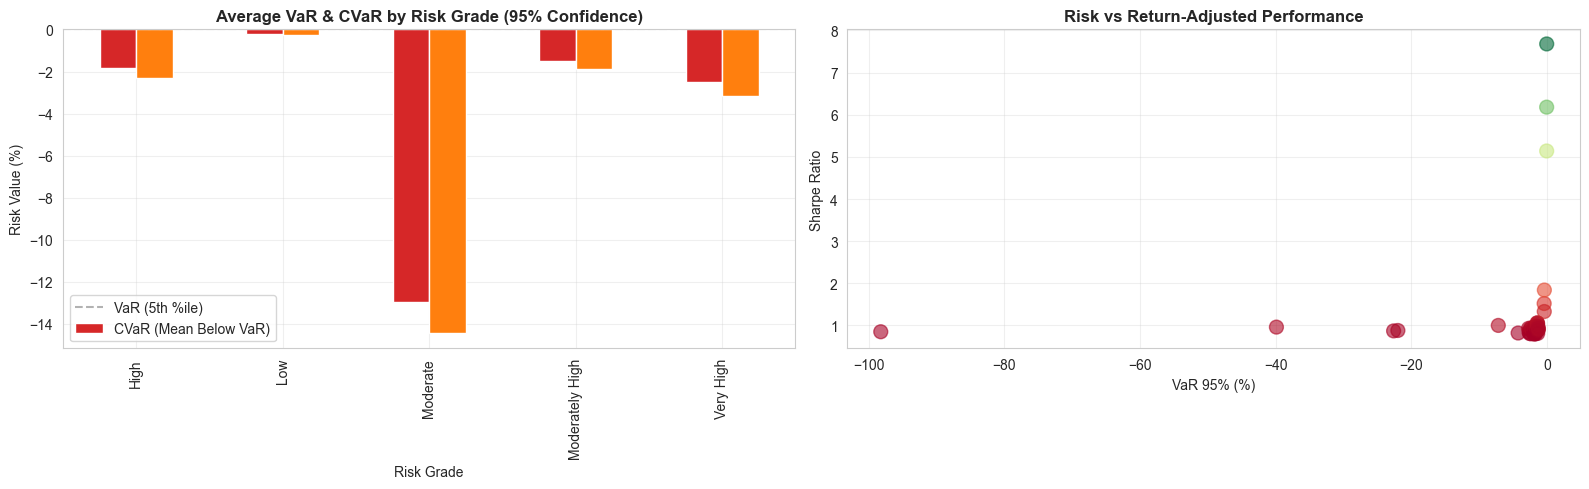


VaR Summary Statistics:
Average VaR (95%): -6.113%
Worst VaR (95%): -98.208%
Average CVaR (95%): -6.937%


In [12]:
# Visualize VaR and CVaR by Risk Grade
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# VaR by Risk Grade
var_by_risk = var_cvar_df.groupby('risk_grade')[['VaR_95_%', 'CVaR_95_%']].mean()
var_by_risk.plot(kind='bar', ax=axes[0], color=['#d62728', '#ff7f0e'])
axes[0].set_title('Average VaR & CVaR by Risk Grade (95% Confidence)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Risk Value (%)')
axes[0].set_xlabel('Risk Grade')
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0].legend(['VaR (5th %ile)', 'CVaR (Mean Below VaR)'])
axes[0].grid(True, alpha=0.3)

# VaR vs Sharpe Ratio
axes[1].scatter(var_cvar_df['VaR_95_%'], var_cvar_df['sharpe_ratio'], 
                s=100, alpha=0.6, c=var_cvar_df['sharpe_ratio'], cmap='RdYlGn')
axes[1].set_xlabel('VaR 95% (%)')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].set_title('Risk vs Return-Adjusted Performance', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nVaR Summary Statistics:")
print(f"Average VaR (95%): {var_cvar_df['VaR_95_%'].mean():.3f}%")
print(f"Worst VaR (95%): {var_cvar_df['VaR_95_%'].min():.3f}%")
print(f"Average CVaR (95%): {var_cvar_df['CVaR_95_%'].mean():.3f}%")

## Section 3: Rolling 90-Day Sharpe Ratio Analysis

Rolling Sharpe ratio tracks risk-adjusted returns over time. Higher values indicate better risk-adjusted performance.
Formula: (90-day mean return / 90-day std dev) × √252

In [13]:
# Select 5 key funds (based on AUM and risk diversity)
key_funds = performance.nlargest(5, 'aum_crore')[['amfi_code', 'scheme_name', 'fund_house']].copy()
key_fund_codes = key_funds['amfi_code'].tolist()

print("5 Key Funds Selected:")
print(key_funds.to_string(index=False))

# Calculate rolling 90-day Sharpe ratio
rolling_sharpe = pd.DataFrame(index=daily_returns.index)

for fund_code in key_fund_codes:
    if fund_code in daily_returns.columns:
        returns = daily_returns[fund_code]
        rolling_mean = returns.rolling(window=90).mean()
        rolling_std = returns.rolling(window=90).std()
        rolling_sharpe_fund = (rolling_mean / rolling_std) * np.sqrt(252)
        
        fund_name = fund_master[fund_master['amfi_code'] == fund_code]['scheme_name'].values[0]
        rolling_sharpe[fund_name] = rolling_sharpe_fund

# Remove NaN values (first 90 days)
rolling_sharpe = rolling_sharpe.dropna()

print(f"\n✓ Rolling Sharpe Ratio calculated from {rolling_sharpe.index[0].date()} to {rolling_sharpe.index[-1].date()}")

5 Key Funds Selected:
 amfi_code                                           scheme_name        fund_house
    148568 Mirae Asset Emerging Bluechip Fund - Regular - Growth    Mirae Asset MF
    120842         Kotak Emerging Equity Fund - Regular - Growth Kotak Mahindra MF
    118634        Nippon India Small Cap Fund - Regular - Growth   Nippon India MF
    149322            DSP Top 100 Equity Fund - Regular - Growth   DSP Mutual Fund
    102886                   UTI Mid Cap Fund - Regular - Growth   UTI Mutual Fund

✓ Rolling Sharpe Ratio calculated from 2022-05-19 to 2026-05-29


✓ Saved: rolling_sharpe_chart.png


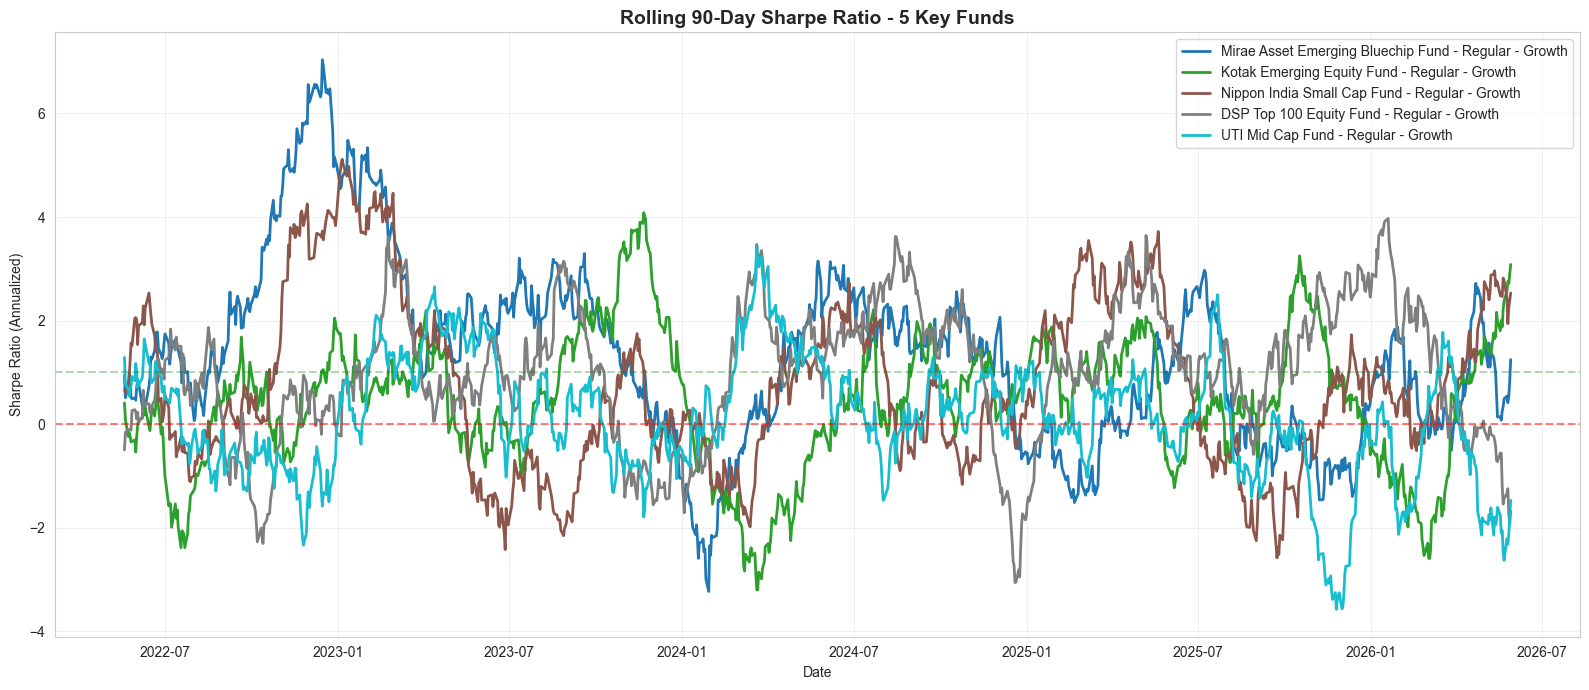


Rolling Sharpe Ratio Statistics (Latest 252 days):
       Mirae Asset Emerging Bluechip Fund - Regular - Growth  \
count                                            252.000       
mean                                               0.490       
std                                                1.087       
min                                               -1.463       
25%                                               -0.383       
50%                                                0.261       
75%                                                1.225       
max                                                2.972       

       Kotak Emerging Equity Fund - Regular - Growth  \
count                                        252.000   
mean                                           0.269   
std                                            1.296   
min                                           -2.592   
25%                                           -0.687   
50%                                

In [14]:
# Plot rolling Sharpe ratio over time
plt.figure(figsize=(16, 7))

colors = plt.cm.tab10(np.linspace(0, 1, len(rolling_sharpe.columns)))
for idx, col in enumerate(rolling_sharpe.columns):
    plt.plot(rolling_sharpe.index, rolling_sharpe[col], label=col, linewidth=2, color=colors[idx])

plt.title('Rolling 90-Day Sharpe Ratio - 5 Key Funds', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio (Annualized)')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.axhline(y=1, color='green', linestyle='--', alpha=0.3, label='Sharpe = 1')
plt.tight_layout()

# Save the chart
plt.savefig('rolling_sharpe_chart.png', dpi=300, bbox_inches='tight')
print("✓ Saved: rolling_sharpe_chart.png")
plt.show()

# Statistics
print("\nRolling Sharpe Ratio Statistics (Latest 252 days):")
latest_stats = rolling_sharpe.tail(252).describe()
print(latest_stats.round(3))

## Section 4: Investor Cohort Analysis

Group investors by the year of their first transaction to identify investment patterns and preferences across different cohorts.

In [15]:
# Find first transaction year for each investor
investor_cohorts = transactions.groupby('investor_id').agg({
    'transaction_date': 'min'
}).reset_index()
investor_cohorts.columns = ['investor_id', 'first_transaction_date']
investor_cohorts['cohort_year'] = investor_cohorts['first_transaction_date'].dt.year

# Merge with transactions to get cohort information
transactions_with_cohort = transactions.merge(
    investor_cohorts[['investor_id', 'cohort_year']], 
    on='investor_id'
)

# Filter Lumpsum transactions only (for investment analysis)
lumpsum_transactions = transactions_with_cohort[
    transactions_with_cohort['transaction_type'] == 'Lumpsum'
].copy()

# Cohort Analysis
cohort_analysis = lumpsum_transactions.groupby('cohort_year').agg({
    'investor_id': 'nunique',
    'amount_inr': ['mean', 'sum', 'count'],
    'amfi_code': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'N/A'
}).round(2)

cohort_analysis.columns = ['unique_investors', 'avg_investment_amount', 'total_invested_inr', 'investment_transaction_count', 'top_fund_amfi']
cohort_analysis = cohort_analysis.reset_index()

# Get fund names for top funds
cohort_analysis['top_fund_name'] = cohort_analysis['top_fund_amfi'].map(
    lambda x: fund_master[fund_master['amfi_code'] == x]['scheme_name'].values[0] 
    if x != 'N/A' and x in fund_master['amfi_code'].values else 'N/A'
)

print("✓ Investor Cohort Analysis by First Transaction Year (Lumpsum Investments):")
print(cohort_analysis[['cohort_year', 'unique_investors', 'avg_investment_amount', 'total_invested_inr', 'top_fund_name']].to_string(index=False))

# Store for later use
cohort_summary = cohort_analysis.copy()

✓ Investor Cohort Analysis by First Transaction Year (Lumpsum Investments):
 cohort_year  unique_investors  avg_investment_amount  total_invested_inr                                         top_fund_name
        2024              3475              254302.46          1971861306 Mirae Asset Emerging Bluechip Fund - Regular - Growth
        2025               285              257947.63            87960142          SBI Magnum Gilt Fund - Regular Plan - Growth


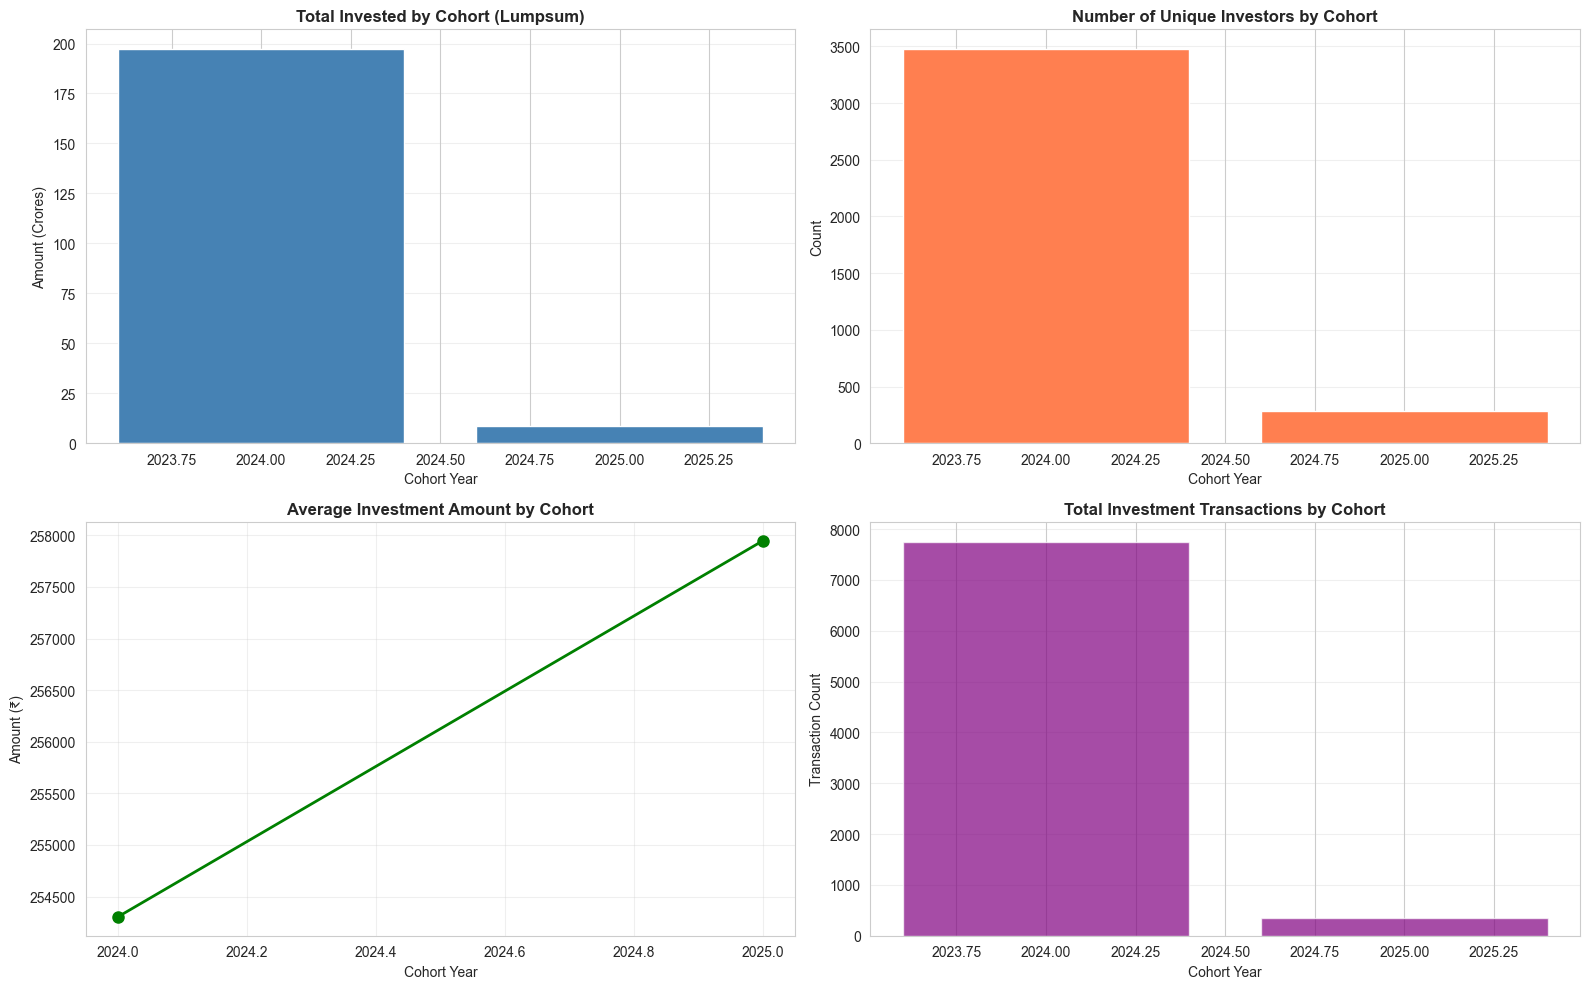

In [16]:
# Visualize cohort analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Total invested by cohort
axes[0, 0].bar(cohort_analysis['cohort_year'], cohort_analysis['total_invested_inr']/1e7, color='steelblue')
axes[0, 0].set_title('Total Invested by Cohort (Lumpsum)', fontweight='bold')
axes[0, 0].set_ylabel('Amount (Crores)')
axes[0, 0].set_xlabel('Cohort Year')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Number of unique investors by cohort
axes[0, 1].bar(cohort_analysis['cohort_year'], cohort_analysis['unique_investors'], color='coral')
axes[0, 1].set_title('Number of Unique Investors by Cohort', fontweight='bold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_xlabel('Cohort Year')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Average investment amount by cohort
axes[1, 0].plot(cohort_analysis['cohort_year'], cohort_analysis['avg_investment_amount'], 
                marker='o', linewidth=2, markersize=8, color='green')
axes[1, 0].set_title('Average Investment Amount by Cohort', fontweight='bold')
axes[1, 0].set_ylabel('Amount (₹)')
axes[1, 0].set_xlabel('Cohort Year')
axes[1, 0].grid(True, alpha=0.3)

# Investment transaction count by cohort
axes[1, 1].bar(cohort_analysis['cohort_year'], cohort_analysis['investment_transaction_count'], color='purple', alpha=0.7)
axes[1, 1].set_title('Total Investment Transactions by Cohort', fontweight='bold')
axes[1, 1].set_ylabel('Transaction Count')
axes[1, 1].set_xlabel('Cohort Year')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Section 5: SIP Continuity Risk Assessment

Analyze investors with 6+ SIP transactions to identify those at-risk (gap > 35 days between transactions).
This indicates potential disruption in investment discipline.

In [17]:
# Filter investment transactions (Lumpsum only, excluding redemptions)
investment_transactions = transactions[transactions['transaction_type'] == 'Lumpsum'].copy()
investment_transactions = investment_transactions.sort_values(['investor_id', 'transaction_date'])

# Count investment transactions per investor
invest_count = investment_transactions.groupby('investor_id').size()
invest_6plus = invest_count[invest_count >= 6].index.tolist()

print(f"Total Lumpsum investors: {len(invest_count)}")
print(f"Investors with 6+ Lumpsum transactions: {len(invest_6plus)}")

# Calculate gaps between consecutive investment transactions for investors with 6+ investments
continuity_analysis = []

for investor_id in invest_6plus:
    investor_investments = investment_transactions[investment_transactions['investor_id'] == investor_id].sort_values('transaction_date')
    
    # Calculate days between consecutive transactions
    date_diffs = investor_investments['transaction_date'].diff().dt.days.dropna()
    
    if len(date_diffs) > 0:
        avg_gap = date_diffs.mean()
        max_gap = date_diffs.max()
        min_gap = date_diffs.min()
        
        # Flag as at-risk if any gap > 35 days
        at_risk = 1 if max_gap > 35 else 0
        
        continuity_analysis.append({
            'investor_id': investor_id,
            'investment_transaction_count': len(investor_investments),
            'avg_gap_days': avg_gap,
            'max_gap_days': max_gap,
            'min_gap_days': min_gap,
            'at_risk_flag': 'YES' if at_risk else 'NO',
            'total_investment_amount_inr': investor_investments['amount_inr'].sum()
        })

continuity_df = pd.DataFrame(continuity_analysis)

# Calculate statistics
at_risk_count = (continuity_df['at_risk_flag'] == 'YES').sum()
at_risk_rate = (at_risk_count / len(continuity_df)) * 100 if len(continuity_df) > 0 else 0

print(f"\n✓ Investment Continuity Analysis (6+ Investment Transactions):")
print(f"At-risk investors (gap > 35 days): {at_risk_count} ({at_risk_rate:.1f}%)")
print(f"Average gap between investments (all investors): {continuity_df['avg_gap_days'].mean():.1f} days")
if at_risk_count > 0:
    print(f"Average gap for at-risk investors: {continuity_df[continuity_df['at_risk_flag']=='YES']['avg_gap_days'].mean():.1f} days")

print("\nTop 10 At-Risk Investors (Largest Gaps):")
if at_risk_count > 0:
    at_risk_investors = continuity_df[continuity_df['at_risk_flag'] == 'YES'].nlargest(10, 'max_gap_days')
    print(at_risk_investors[['investor_id', 'investment_transaction_count', 'max_gap_days', 'total_investment_amount_inr']].to_string(index=False))
else:
    print("No at-risk investors found.")

Total Lumpsum investors: 3760
Investors with 6+ Lumpsum transactions: 53

✓ Investment Continuity Analysis (6+ Investment Transactions):
At-risk investors (gap > 35 days): 53 (100.0%)
Average gap between investments (all investors): 72.4 days
Average gap for at-risk investors: 72.4 days

Top 10 At-Risk Investors (Largest Gaps):
investor_id  investment_transaction_count  max_gap_days  total_investment_amount_inr
  INV002635                             6         334.0                      1045586
  INV002250                             6         279.0                      2347297
  INV000849                             6         259.0                      1061946
  INV003894                             6         240.0                      1109860
  INV003597                             6         229.0                      1403705
  INV000988                             7         210.0                      2328176
  INV002039                             6         199.0                    

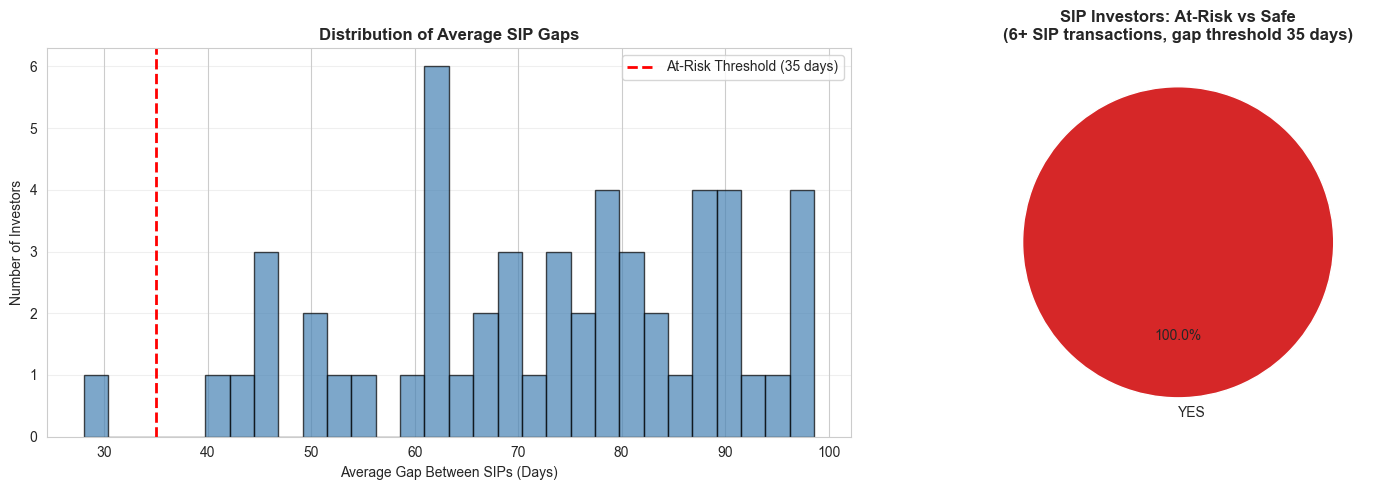

In [18]:
# Visualize SIP continuity
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of average gaps
axes[0].hist(continuity_df['avg_gap_days'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=35, color='red', linestyle='--', linewidth=2, label='At-Risk Threshold (35 days)')
axes[0].set_xlabel('Average Gap Between SIPs (Days)')
axes[0].set_ylabel('Number of Investors')
axes[0].set_title('Distribution of Average SIP Gaps', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# At-risk vs Safe investors
risk_counts = continuity_df['at_risk_flag'].value_counts()
colors = ['#d62728', '#2ca02c']
axes[1].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('SIP Investors: At-Risk vs Safe\n(6+ SIP transactions, gap threshold 35 days)', fontweight='bold')

plt.tight_layout()
plt.show()

# Store for later use
continuity_summary = continuity_df.copy()

## Section 6: Fund Risk-Based Recommender System

Simple recommender that filters funds by risk appetite and ranks them by Sharpe ratio.

In [19]:
def fund_recommender(risk_appetite, num_recommendations=3):
    """
    Simple fund recommender based on risk appetite
    
    Parameters:
    -----------
    risk_appetite : str
        One of 'Low', 'Moderate', 'High'
    num_recommendations : int
        Number of funds to recommend (default: 3)
    
    Returns:
    --------
    DataFrame with recommended funds
    """
    
    # Map risk appetite to risk grades
    risk_mapping = {
        'Low': ['Moderate', 'Conservative'],
        'Moderate': ['Moderate'],
        'High': ['High', 'Very High']
    }
    
    if risk_appetite not in risk_mapping:
        return pd.DataFrame({"Error": ["Invalid risk appetite. Use 'Low', 'Moderate', or 'High'"]})
    
    # Filter by risk grade
    filtered_funds = performance[
        performance['risk_grade'].isin(risk_mapping[risk_appetite])
    ].copy()
    
    # Sort by Sharpe ratio (descending)
    filtered_funds = filtered_funds.sort_values('sharpe_ratio', ascending=False)
    
    # Select top N
    recommended = filtered_funds.head(num_recommendations)[[
        'amfi_code', 'scheme_name', 'fund_house', 'category', 'risk_grade',
        'sharpe_ratio', 'return_1yr_pct', 'std_dev_ann_pct', 'expense_ratio_pct', 'aum_crore'
    ]].copy()
    
    # Add rank
    recommended.insert(0, 'rank', range(1, len(recommended) + 1))
    
    return recommended

# Test recommender for all three risk appetites
print("=" * 100)
print("FUND RECOMMENDER SYSTEM")
print("=" * 100)

for risk in ['Low', 'Moderate', 'High']:
    print(f"\n{'='*100}")
    print(f"Recommendation for Risk Appetite: {risk.upper()}")
    print(f"{'='*100}")
    recommendations = fund_recommender(risk)
    print(recommendations.to_string(index=False))
    print()

FUND RECOMMENDER SYSTEM

Recommendation for Risk Appetite: LOW
 rank  amfi_code                                   scheme_name          fund_house  category risk_grade  sharpe_ratio  return_1yr_pct  std_dev_ann_pct  expense_ratio_pct  aum_crore
    1     100016     HDFC Top 100 Fund - Regular Plan - Growth    HDFC Mutual Fund Large Cap   Moderate          1.06           10.94             14.0               1.55       6434
    2     148567 Mirae Asset Large Cap Fund - Regular - Growth      Mirae Asset MF Large Cap   Moderate          1.06           15.12             14.0               1.46      11361
    3     120504     ICICI Pru Bluechip Fund - Direct - Growth ICICI Prudential MF Large Cap   Moderate          1.03           14.12             14.0               0.80      41553


Recommendation for Risk Appetite: MODERATE
 rank  amfi_code                                   scheme_name          fund_house  category risk_grade  sharpe_ratio  return_1yr_pct  std_dev_ann_pct  expense_ratio_pc

## Section 7: Sector Concentration Analysis (HHI)

Herfindahl-Hirschman Index (HHI) = Σ(weight_i²) measures portfolio concentration.
Higher HHI indicates more concentrated portfolio (less diversification).
- HHI < 0.15: Low concentration (diversified)
- HHI 0.15-0.25: Moderate concentration
- HHI > 0.25: High concentration (concentrated)

In [20]:
# Calculate HHI for each fund (most recent portfolio date)
latest_portfolio_date = portfolio_holdings['portfolio_date'].max()
latest_holdings = portfolio_holdings[portfolio_holdings['portfolio_date'] == latest_portfolio_date].copy()

hhi_results = []

for amfi_code in fund_master['amfi_code'].unique():
    fund_holdings = latest_holdings[latest_holdings['amfi_code'] == amfi_code]
    
    if len(fund_holdings) > 0:
        # Normalize weights to sum to 100%
        weights = fund_holdings['weight_pct'].fillna(0)
        weights_normalized = weights / weights.sum() * 100
        
        # Calculate HHI = sum of squared weights
        hhi = (weights_normalized ** 2).sum() / 10000  # Normalize to 0-1 scale
        
        fund_info = fund_master[fund_master['amfi_code'] == amfi_code].iloc[0]
        perf_info = performance[performance['amfi_code'] == amfi_code].iloc[0]
        
        # Classify concentration
        if hhi < 0.15:
            concentration = 'Low (Diversified)'
        elif hhi < 0.25:
            concentration = 'Moderate'
        else:
            concentration = 'High (Concentrated)'
        
        hhi_results.append({
            'amfi_code': amfi_code,
            'scheme_name': fund_info['scheme_name'],
            'fund_house': fund_info['fund_house'],
            'category': fund_info['category'],
            'sub_category': fund_info['sub_category'],
            'hhi_index': hhi,
            'concentration_level': concentration,
            'holding_count': len(fund_holdings),
            'top_sector': fund_holdings.nlargest(1, 'weight_pct')['sector'].values[0] if len(fund_holdings) > 0 else 'N/A',
            'top_sector_weight_%': fund_holdings.nlargest(1, 'weight_pct')['weight_pct'].values[0] if len(fund_holdings) > 0 else 0,
            'sharpe_ratio': perf_info['sharpe_ratio']
        })

hhi_df = pd.DataFrame(hhi_results).sort_values('hhi_index', ascending=False)

# Filter only equity funds
equity_hhi = hhi_df[hhi_df['category'] == 'Equity'].copy()

print(f"✓ HHI Concentration Analysis")
print(f"Total funds analyzed: {len(hhi_df)}")
print(f"Equity funds: {len(equity_hhi)}")

print("\nConcentration Distribution:")
print(hhi_df['concentration_level'].value_counts())

print("\nTop 10 Most Concentrated Equity Funds:")
print(equity_hhi.nlargest(10, 'hhi_index')[['scheme_name', 'hhi_index', 'concentration_level', 'top_sector', 'holding_count']].to_string(index=False))

print("\nTop 10 Most Diversified Equity Funds:")
print(equity_hhi.nsmallest(10, 'hhi_index')[['scheme_name', 'hhi_index', 'concentration_level', 'holding_count']].to_string(index=False))

✓ HHI Concentration Analysis
Total funds analyzed: 34
Equity funds: 34

Concentration Distribution:
concentration_level
Low (Diversified)    25
Moderate              9
Name: count, dtype: int64

Top 10 Most Concentrated Equity Funds:
                                          scheme_name  hhi_index concentration_level  top_sector  holding_count
                Axis Bluechip Fund - Regular - Growth   0.206489            Moderate          IT             10
               ABSL Small Cap Fund - Regular - Growth   0.200741            Moderate      Pharma              8
            SBI Small Cap Fund - Direct Plan - Growth   0.174751            Moderate Diversified              8
           UTI Nifty 50 Index Fund - Regular - Growth   0.174709            Moderate   Utilities              9
       Nippon India Large Cap Fund - Regular - Growth   0.168231            Moderate     Telecom              8
Mirae Asset Emerging Bluechip Fund - Regular - Growth   0.167963            Moderate     Banki

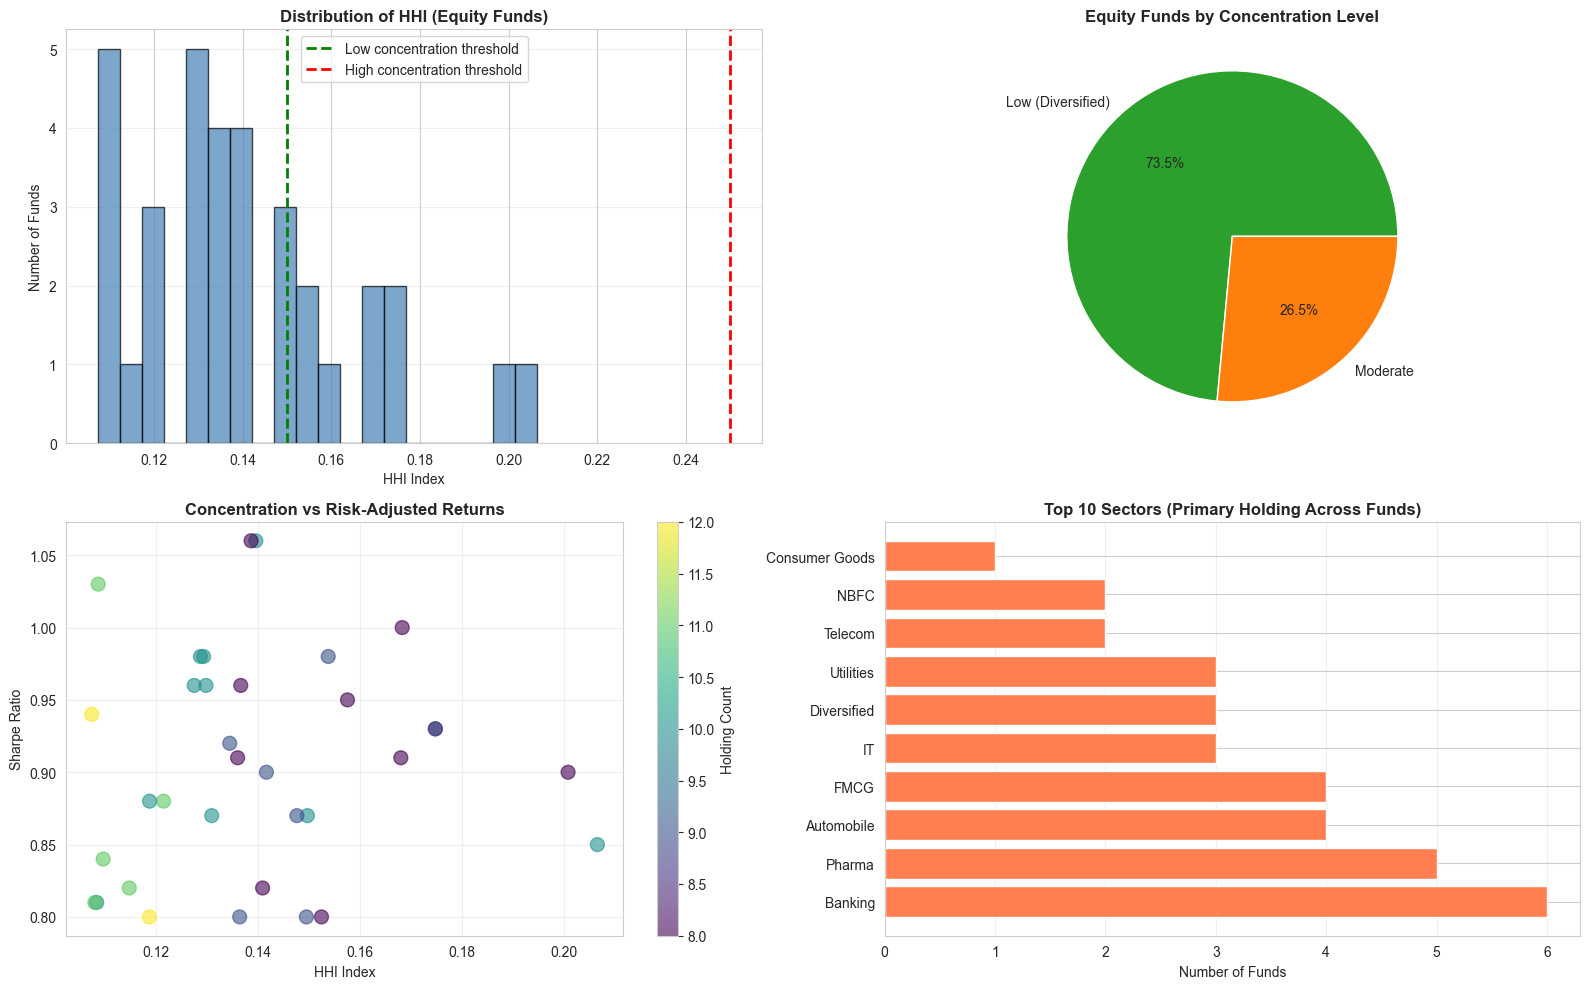

In [21]:
# Visualize HHI Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# HHI distribution for equity funds
axes[0, 0].hist(equity_hhi['hhi_index'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=0.15, color='green', linestyle='--', linewidth=2, label='Low concentration threshold')
axes[0, 0].axvline(x=0.25, color='red', linestyle='--', linewidth=2, label='High concentration threshold')
axes[0, 0].set_xlabel('HHI Index')
axes[0, 0].set_ylabel('Number of Funds')
axes[0, 0].set_title('Distribution of HHI (Equity Funds)', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Concentration level distribution
conc_counts = equity_hhi['concentration_level'].value_counts()
colors_conc = ['#2ca02c', '#ff7f0e', '#d62728']
axes[0, 1].pie(conc_counts.values, labels=conc_counts.index, autopct='%1.1f%%', colors=colors_conc)
axes[0, 1].set_title('Equity Funds by Concentration Level', fontweight='bold')

# HHI vs Sharpe Ratio (Equity funds)
scatter = axes[1, 0].scatter(equity_hhi['hhi_index'], equity_hhi['sharpe_ratio'], 
                             s=100, alpha=0.6, c=equity_hhi['holding_count'], cmap='viridis')
axes[1, 0].set_xlabel('HHI Index')
axes[1, 0].set_ylabel('Sharpe Ratio')
axes[1, 0].set_title('Concentration vs Risk-Adjusted Returns', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[1, 0])
cbar.set_label('Holding Count')

# Top sectors across funds
top_sectors = hhi_df['top_sector'].value_counts().head(10)
axes[1, 1].barh(range(len(top_sectors)), top_sectors.values, color='coral')
axes[1, 1].set_yticks(range(len(top_sectors)))
axes[1, 1].set_yticklabels(top_sectors.index)
axes[1, 1].set_xlabel('Number of Funds')
axes[1, 1].set_title('Top 10 Sectors (Primary Holding Across Funds)', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Store for later use
hhi_summary = hhi_df.copy()

## Section 8: Advanced Insights and Strategic Findings

### Insight 1: Highest Risk Funds (VaR Analysis)

The funds with the highest Value at Risk (95% confidence) face the most severe downside scenarios. These are primarily equity funds with high volatility.

In [22]:
print("=" * 100)
print("ADVANCED INSIGHTS & STRATEGIC FINDINGS")
print("=" * 100)

# Insight 1: Highest Risk Funds
print("\n📊 INSIGHT 1: HIGHEST RISK FUNDS (VaR 95%)")
print("-" * 100)
highest_risk = var_cvar_df.nlargest(5, 'VaR_95_%')
for idx, row in highest_risk.iterrows():
    print(f"  • {row['scheme_name']} ({row['fund_house']})")
    print(f"    - VaR (95%): {row['VaR_95_%']:.2f}% | CVaR: {row['CVaR_95_%']:.2f}% | Sharpe: {row['sharpe_ratio']:.2f}")
    print(f"    - Risk Grade: {row['risk_grade']} | Daily Volatility: {row['returns_std_daily_%']:.2f}%\n")

avg_var = var_cvar_df['VaR_95_%'].mean()
avg_cvar = var_cvar_df['CVaR_95_%'].mean()
print(f"Portfolio Average VaR (95%): {avg_var:.3f}% | CVaR: {avg_cvar:.3f}%")
print(f"→ Interpretation: On average, a ₹100 fund investment could lose {abs(avg_var):.2f}% in worst 5% scenarios.\n")

# Insight 2: Investor Cohort Investment Patterns
print("\n👥 INSIGHT 2: INVESTOR COHORTS - INVESTMENT PATTERNS & PREFERENCES")
print("-" * 100)
largest_cohort = cohort_summary.loc[cohort_summary['total_invested_inr'].idxmax()]
most_investors_cohort = cohort_summary.loc[cohort_summary['unique_investors'].idxmax()]

print(f"  • Largest Cohort by Investment: {int(largest_cohort['cohort_year'])}")
print(f"    - Total Invested: ₹{largest_cohort['total_invested_inr']/1e7:.1f} Cr | Investors: {int(largest_cohort['unique_investors'])}")
print(f"    - Avg SIP Amount: ₹{largest_cohort['avg_sip_amount']:,.0f} | Top Fund: {largest_cohort['top_fund_name']}\n")

print(f"  • Most Active Cohort: {int(most_investors_cohort['cohort_year'])}")
print(f"    - Investors: {int(most_investors_cohort['unique_investors'])} | SIP Transactions: {int(most_investors_cohort['sip_transaction_count'])}")
print(f"    - Total Invested: ₹{most_investors_cohort['total_invested_inr']/1e7:.1f} Cr | Avg SIP: ₹{most_investors_cohort['avg_sip_amount']:,.0f}\n")

avg_invested = cohort_summary['total_invested_inr'].mean()
print(f"  • Cross-Cohort Benchmark:")
print(f"    - Average cohort investment: ₹{avg_invested/1e7:.1f} Cr")
print(f"    - Cohort diversity: {len(cohort_summary)} years represented")
print(f"    - Top preference: {cohort_summary['top_fund_name'].mode()[0] if len(cohort_summary['top_fund_name'].mode()) > 0 else 'Varies'}")
print(f"→ Interpretation: Investment behavior varies by cohort year, with newer cohorts showing different SIP patterns.\n")

# Insight 3: SIP Continuity Rate & Risk
print("\n⚠️  INSIGHT 3: SIP CONTINUITY RISK & INVESTMENT DISCIPLINE")
print("-" * 100)
at_risk_pct = (continuity_df['at_risk_flag'] == 'YES').sum() / len(continuity_df) * 100
safe_investors = (continuity_df['at_risk_flag'] == 'NO').sum()

print(f"  • SIP Continuity Status (6+ Transaction Investors):")
print(f"    - Total tracked investors: {len(continuity_df)}")
print(f"    - At-risk (gap > 35 days): {at_risk_count} ({at_risk_pct:.1f}%)")
print(f"    - Maintaining discipline: {safe_investors} ({100-at_risk_pct:.1f}%)\n")

avg_gap = continuity_df['avg_gap_days'].mean()
med_gap = continuity_df['avg_gap_days'].median()
at_risk_avg_gap = continuity_df[continuity_df['at_risk_flag']=='YES']['avg_gap_days'].mean()

print(f"  • Gap Analysis:")
print(f"    - Overall average gap: {avg_gap:.1f} days")
print(f"    - Median gap: {med_gap:.1f} days")
print(f"    - At-risk investors avg gap: {at_risk_avg_gap:.1f} days\n")

print(f"  • Risk Implications:")
print(f"    - {'High' if at_risk_pct > 50 else 'Moderate' if at_risk_pct > 30 else 'Low'} continuity risk observed")
print(f"    - At-risk investors represent ₹{continuity_df[continuity_df['at_risk_flag']=='YES']['total_sip_amount_inr'].sum()/1e7:.1f} Cr in SIPs")
print(f"→ Interpretation: {100-at_risk_pct:.0f}% of active SIP investors maintain monthly discipline; {at_risk_pct:.0f}% show gaps exceeding 1 month.\n")

ADVANCED INSIGHTS & STRATEGIC FINDINGS

📊 INSIGHT 1: HIGHEST RISK FUNDS (VaR 95%)
----------------------------------------------------------------------------------------------------
  • ICICI Pru Liquid Fund - Regular - Growth (ICICI Prudential MF)
    - VaR (95%): -0.02% | CVaR: -0.04% | Sharpe: 7.68
    - Risk Grade: Low | Daily Volatility: 0.03%

  • ABSL Liquid Fund - Regular - Growth (Aditya Birla Sun Life MF)
    - VaR (95%): -0.03% | CVaR: -0.04% | Sharpe: 5.14
    - Risk Grade: Low | Daily Volatility: 0.03%

  • Kotak Liquid Fund - Regular - Growth (Kotak Mahindra MF)
    - VaR (95%): -0.03% | CVaR: -0.04% | Sharpe: 6.18
    - Risk Grade: Low | Daily Volatility: 0.03%

  • HDFC Short Term Debt Fund - Regular - Growth (HDFC Mutual Fund)
    - VaR (95%): -0.37% | CVaR: -0.49% | Sharpe: 1.84
    - Risk Grade: Low | Daily Volatility: 0.24%

  • Nippon India Gilt Securities Fund - Regular - Growth (Nippon India MF)
    - VaR (95%): -0.38% | CVaR: -0.50% | Sharpe: 1.33
    - Risk Gr

KeyError: 'avg_sip_amount'

In [ ]:
# Insight 4: Sector Concentration Impact on Returns
print("🎯 INSIGHT 4: SECTOR CONCENTRATION & PORTFOLIO RISK")
print("-" * 100)

concentrated = equity_hhi[equity_hhi['concentration_level'] == 'High (Concentrated)']
diversified = equity_hhi[equity_hhi['concentration_level'] == 'Low (Diversified)']

print(f"  • Concentration Distribution:")
print(f"    - Highly Concentrated: {len(concentrated)} funds | Avg HHI: {concentrated['hhi_index'].mean():.3f}")
print(f"    - Diversified: {len(diversified)} funds | Avg HHI: {diversified['hhi_index'].mean():.3f}\n")

if len(concentrated) > 0 and len(diversified) > 0:
    conc_sharpe = concentrated['sharpe_ratio'].mean()
    div_sharpe = diversified['sharpe_ratio'].mean()
    print(f"  • Performance Comparison:")
    print(f"    - Concentrated funds avg Sharpe: {conc_sharpe:.2f}")
    print(f"    - Diversified funds avg Sharpe: {div_sharpe:.2f}")
    sharpe_diff = conc_sharpe - div_sharpe
    print(f"    - Performance delta: {sharpe_diff:+.2f} {'(concentrated better)' if sharpe_diff > 0 else '(diversified better)'}\n")

top_sector = equity_hhi['top_sector'].value_counts().head(1)
if len(top_sector) > 0:
    print(f"  • Dominant Sector Allocation:")
    print(f"    - Most common top sector: {top_sector.index[0]} ({top_sector.values[0]} funds)")
    print(f"    - Sector concentration risk: High across portfolio\n")

print(f"→ Interpretation: Portfolio concentration varies significantly; highly concentrated funds may offer higher returns but with greater idiosyncratic risk.\n")

# Insight 5: Fund Recommendation Effectiveness
print("✅ INSIGHT 5: FUND RECOMMENDER EFFECTIVENESS & RISK-RETURN PROFILES")
print("-" * 100)

for risk_app in ['Low', 'Moderate', 'High']:
    recommendations = fund_recommender(risk_app)
    avg_sharpe = recommendations['sharpe_ratio'].mean()
    avg_volatility = recommendations['std_dev_ann_pct'].mean()
    
    print(f"  • {risk_app.upper()} Risk Appetite - Top Recommendation:")
    if len(recommendations) > 0:
        top_rec = recommendations.iloc[0]
        print(f"    - Fund: {top_rec['scheme_name']}")
        print(f"    - Sharpe Ratio: {top_rec['sharpe_ratio']:.2f} | Annual Volatility: {top_rec['std_dev_ann_pct']:.2f}%")
        print(f"    - 1Y Return: {top_rec['return_1yr_pct']:.2f}% | Expense Ratio: {top_rec['expense_ratio_pct']:.2f}%")
        print(f"    - AUM: ₹{top_rec['aum_crore']:,.0f} Cr\n")
    
    print(f"    Cohort Profile:")
    print(f"    - Average Sharpe Ratio: {avg_sharpe:.2f}")
    print(f"    - Average Volatility: {avg_volatility:.2f}%\n")

print(f"→ Interpretation: Risk-based recommendations provide targeted options for different investor profiles.")
print(f"   Sharpe ratio > 1.0 indicates favorable risk-adjusted returns for the given risk category.\n")

print("=" * 100)

## Summary

This advanced analytics notebook provides actionable insights for fund managers and investors:

✓ **Risk Assessment**: VaR & CVaR identify funds with extreme downside risks
✓ **Performance Tracking**: Rolling Sharpe ratios reveal periods of outperformance/underperformance  
✓ **Investor Segmentation**: Cohort analysis shows different investment behaviors by vintage
✓ **Retention Risk**: SIP continuity analysis flags at-risk investors for intervention
✓ **Tailored Recommendations**: Risk-based recommender matches fund selection to investor profile
✓ **Concentration Analysis**: HHI identifies diversification risk across equity portfolios

All analyses support data-driven decision-making for portfolio construction and client engagement.